## Name: plot_timeseries.ipynb

Author: Robby M. Frost

University of Oklahoma

Created: 11 November 2024

Purpose: Plot timeseries of lidar observed vorticity statistics

In [24]:
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr
from functions import *
import matplotlib.pyplot as plt
from matplotlib import rc
from matplotlib.ticker import MultipleLocator
import matplotlib.dates as mdates
import datetime
import seaborn

Read in time series data

In [25]:
# directory where time series are stored
dts = "/data/arrcwx/robbyfrost/lidar_obs/"
# date/time info of lidar scans
des_year = "2024"
des_mon = "11"
des_days = ["01", "02", "03"]
# des_days = ["1029", "1030", "1031", '1101', '1102', '1103']
des_sys = "ARRC" # WG100-L0AD00003JP, WG100-L0AD00004JP, or ARRC
lidar_loc = "ARRC Mobile" # Hampton, VA or ARRC
des_elev = "5"

# read in time series netcdf
ts_all = []
for des_day in des_days:
    dnc = f"{dts}{des_sys}/{des_year}/{des_mon}/{des_day}/vort_timeseries_el{des_elev}.nc"
    # dnc = f"{dts}{des_sys}/{des_year}/{des_day[:2]}/{des_day[2:]}/vort_timeseries_el{des_elev}.nc"
    ts = xr.open_dataarray(dnc)
    # format time for plotting
    dummy = datetime.date(1900, 1, 1)
    time_only = [np.datetime_as_string(dt, unit='s').split('T')[1] for dt in ts.time.values]
    time_array = np.empty(ts.time.size, dtype=object)
    for i, t in enumerate(time_only):
        hh = int(t[:2])
        mm = int(t[3:5])
        ss = int(t[6:8])
        time = datetime.time(hh,mm,ss)
        time_array[i] = datetime.datetime.combine(dummy, time)
    ts["time"] = time_array
    ts_all.append(ts)

# plotting set up
plt.rcParams['axes.labelweight'] = 'normal'
plt.rcParams['text.latex.preamble'] = r'\usepackage{bm}'
rc('font', family='sans-serif')
rc('font', weight='normal', size=15)
rc('figure', facecolor='white')
day_colors = seaborn.color_palette('flare', len(des_days))

Plot time series of $\langle |\zeta| \rangle$

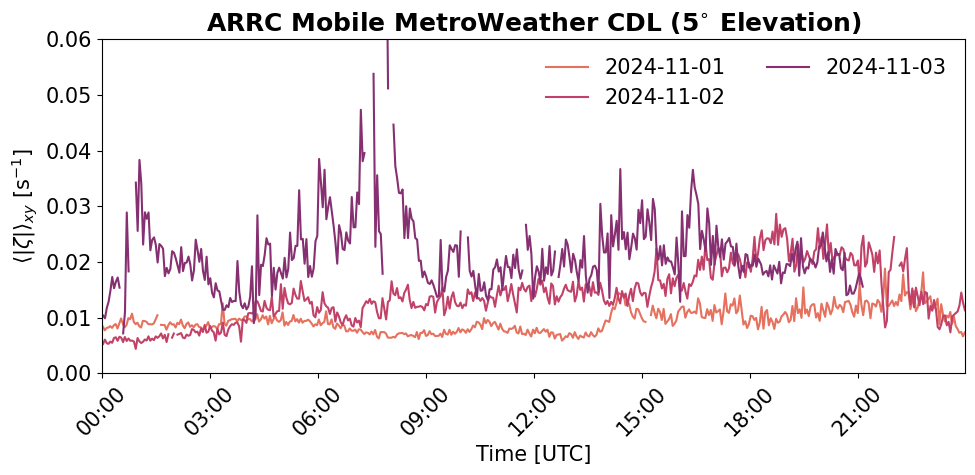

In [26]:
fig, ax = plt.subplots(figsize=(10, 5))

# Loop through each dataset in ts_all and plot
for i, ts in enumerate(ts_all):
    ax.plot(ts.time, ts,
            c=day_colors[i],
            label=f"{des_year}-{des_mon}-{des_days[i]}")
            # label=f"{des_year}-{des_days[i][:2]}-{des_days[i][2:]}")

# Add labels, title, and legend
ax.set_xlabel("Time [UTC]")
plt.xticks(rotation=45)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
ax.yaxis.set_major_locator(MultipleLocator(0.01))
ax.set_ylabel("$\\langle |\\zeta| \\rangle_{xy}$ [s$^{-1}$]")
ax.set_title(f"{lidar_loc} MetroWeather CDL ({des_elev}$^{{\\circ}}$ Elevation)",
             fontweight="bold")
ax.set_xlim([datetime.datetime(dummy.year, dummy.month, dummy.day, 0, 0),
             datetime.datetime(dummy.year, dummy.month, dummy.day, 23, 59)])
ax.set_ylim(0,0.06)

ax.legend(frameon=False, ncols=2)

plt.tight_layout()
plt.show()
